# HW1 - Statistical Testing on E–Commerce data

**Author:** Sepehr Barekati   

---

## Dataset and Libraries

### Introduction:

This project focuses on applying standard statistical hypothesis tests to an Online Retail "E-Commerce Data" dataset using Python. The primary objective is to clean the data, formulate hypotheses, execute the appropriate statistical tests, and interpret the results to understand customer and transactional behavior.

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [78]:
df = pd.read_csv("data.csv", encoding='latin1')

In [79]:
print("Dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
display(df.head(10))
display(df.describe())
display(df.info())


Dataset has 541909 rows and 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None

In [80]:
# keep only rows with Quantity > 0 and unit price > 0
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

In [81]:
# Creating a new variable revenue as Revenue = Quantity × UnitPrice.
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [82]:
# Missing Values
missing_values = df_clean.isnull().sum()
display(missing_values)

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
Revenue             0
dtype: int64

In [83]:
# remove CustomerID and Description columns
df_clean.drop(columns=['CustomerID', 'Description', 'InvoiceNo', 'StockCode'], inplace=True)

In [84]:
print("The new Dataset has {} rows and {} columns".format(df_clean.shape[0], df_clean.shape[1]))
display(df_clean.head(10))
display(df_clean.describe())

The new Dataset has 530104 rows and 5 columns


,Quantity,InvoiceDate,UnitPrice,Country,Revenue
0,6,12/1/2010 8:26,2.55,United Kingdom,15.30
1,6,12/1/2010 8:26,3.39,United Kingdom,20.34
2,8,12/1/2010 8:26,2.75,United Kingdom,22.00
3,6,12/1/2010 8:26,3.39,United Kingdom,20.34
4,6,12/1/2010 8:26,3.39,United Kingdom,20.34
5,2,12/1/2010 8:26,7.65,United Kingdom,15.30
6,6,12/1/2010 8:26,4.25,United Kingdom,25.50
7,6,12/1/2010 8:28,1.85,United Kingdom,11.10
8,6,12/1/2010 8:28,1.85,United Kingdom,11.10
9,32,12/1/2010 8:34,1.69,United Kingdom,54.08


,Quantity,UnitPrice,Revenue
count,530104.000000,530104.000000,530104.000000
mean,10.542037,3.907625,20.121871
std,155.524124,35.915681,270.356743
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,10.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


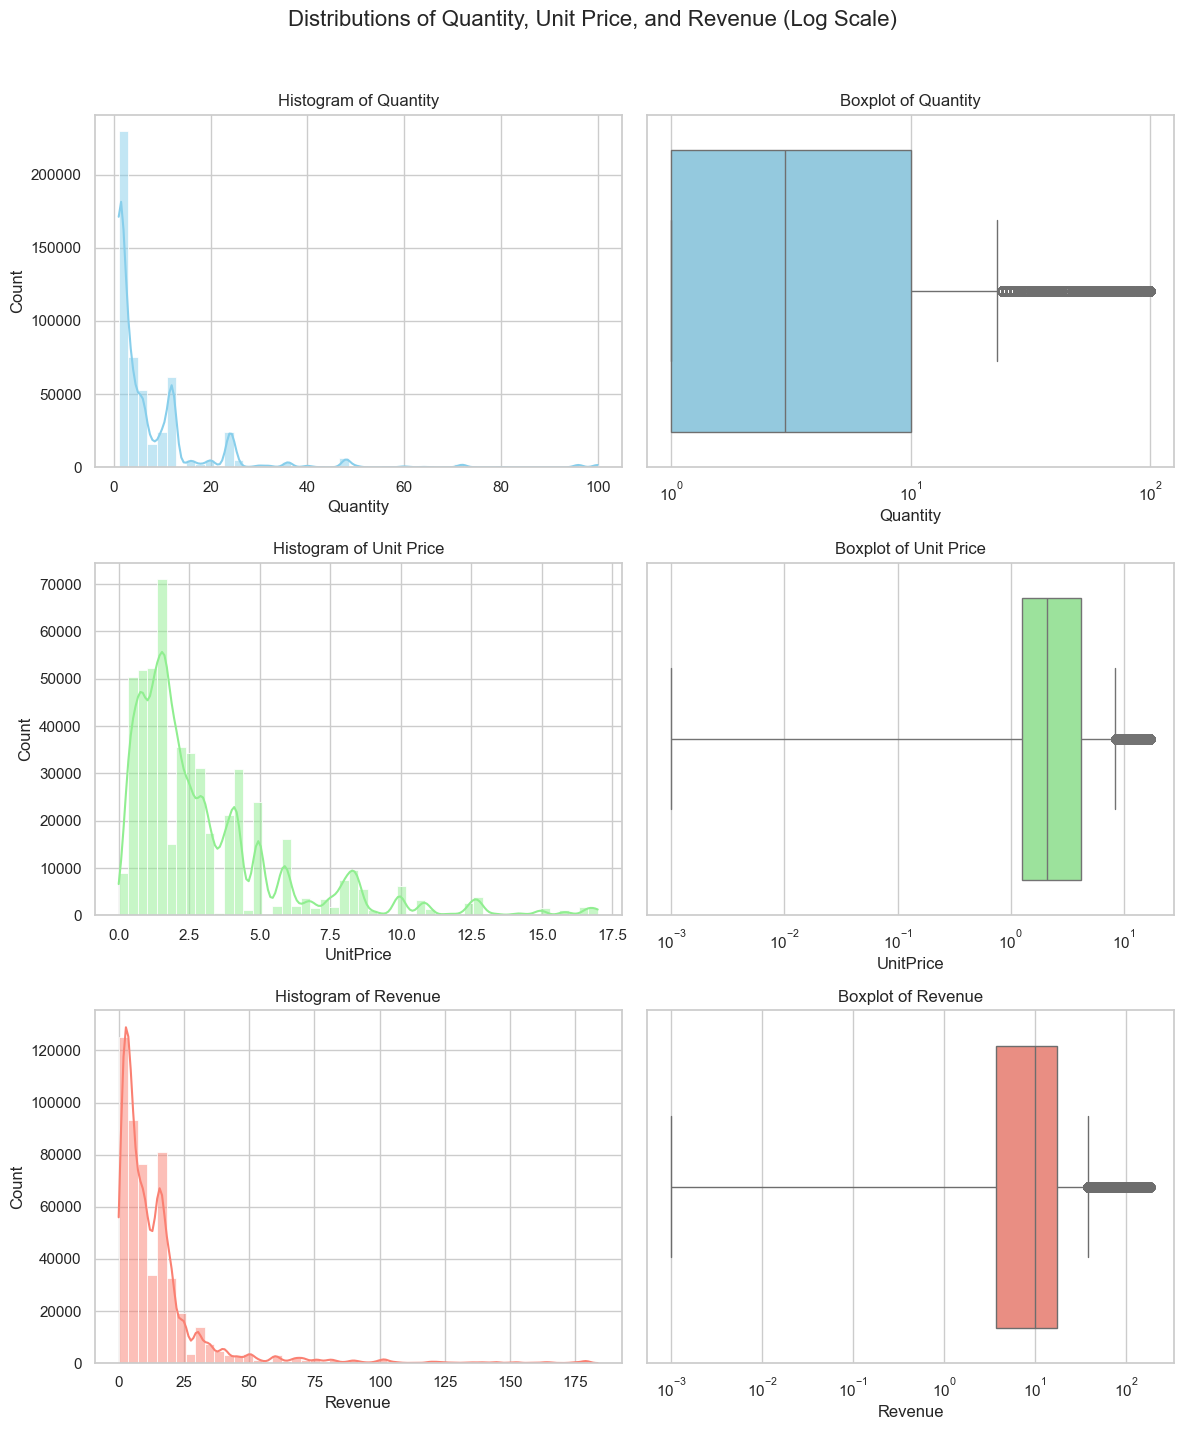

In [85]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle('Distributions of Quantity, Unit Price, and Revenue (Log Scale)', fontsize=16, y=1.02)

# --- 1. Quantity ---
sns.histplot(df_clean[df_clean['Quantity'] <= df_clean['Quantity'].quantile(0.99)]['Quantity'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histogram of Quantity')

sns.boxplot(x=df_clean[df_clean['Quantity'] <= df_clean['Quantity'].quantile(0.99)]['Quantity'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Boxplot of Quantity')
axes[0, 1].set_xscale('log') # Log scale handles extreme outliers

# --- 2. Unit Price ---
sns.histplot(df_clean[df_clean['UnitPrice'] <= df_clean['UnitPrice'].quantile(0.99)]['UnitPrice'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Histogram of Unit Price')

sns.boxplot(x=df_clean[df_clean['UnitPrice'] <= df_clean['UnitPrice'].quantile(0.99)]['UnitPrice'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Boxplot of Unit Price')
axes[1, 1].set_xscale('log')

# --- 3. Revenue ---
sns.histplot(df_clean[df_clean['Revenue'] <= df_clean['Revenue'].quantile(0.99)]['Revenue'], bins=50, kde=True, ax=axes[2, 0], color='salmon')
axes[2, 0].set_title('Histogram of Revenue')

sns.boxplot(x=df_clean[df_clean['Revenue'] <= df_clean['Revenue'].quantile(0.99)]['Revenue'], ax=axes[2, 1], color='salmon')
axes[2, 1].set_title('Boxplot of Revenue')
axes[2, 1].set_xscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### EDA Visual Analysis 
- **Extreme Right-Skewness:** The histograms show that Quantity, Unit Price, and Revenue are all heavily right-skewed. The vast majority of line items consist of low-cost items purchased in small quantities, creating massive spikes on the left side of the charts.
- **Heavy Outliers:** The boxplots (which utilize a logarithmic x-axis to make the spread visible) reveal a dense concentration of extreme outliers stretching far to the right. This indicates a "long tail" of rare but massive wholesale or bulk purchases.
- **Non-Normal Distribution:** Visually, none of the variables resemble a normal bell curve. This perfectly supports the statistical finding in Test 1 that the revenue data significantly violates the normality assumption.

---

### Test 1: Normality of revenue
**Question:** Does the distribution of line item revenue resemble a normal distribution?

**Hypotheses:**
* **$H_0$:** The sampled revenue values come from a normal distribution.
* **$H_1$:** The sampled revenue values do not come from a normal distribution.

**Methodology:**
Because the Shapiro-Wilk test becomes overly sensitive to trivial deviations from normality when the sample size is massive, we will take a random sample of 3,000 observations from our cleaned revenue data. We will then compute the Shapiro-Wilk statistic and visualize the distribution using a histogram with a density plot overlay.

In [86]:
from scipy.stats import shapiro

In [87]:
# 1. Take a random sample of 3000 observations from the revenue column
# We use random_state=42 so you get the exact same sample every time you run the notebook
sample_size = min(3000, len(df_clean))
revenue_sample = df_clean['Revenue'].sample(n=sample_size, random_state=42)

In [88]:
# 2. Run the Shapiro-Wilk Test
stat, p_value = shapiro(revenue_sample)

print("Shapiro-Wilk Test Results")
print("-------------------------")
print(f"Test Statistic: {stat:.4f}")
print(f"P-value:        {p_value:.4e}")

# Basic Interpretation Logic
alpha = 0.05
if p_value > alpha:
    print("\nConclusion: Fail to reject H0 (p > 0.05).")
    print("The sampled revenue values appear to come from a normal distribution.")
else:
    print("\nConclusion: Reject H0 (p <= 0.05).")
    print("The sampled revenue values do NOT come from a normal distribution.")

Shapiro-Wilk Test Results
-------------------------
Test Statistic: 0.3038
P-value:        5.9658e-75

Conclusion: Reject H0 (p <= 0.05).
The sampled revenue values do NOT come from a normal distribution.


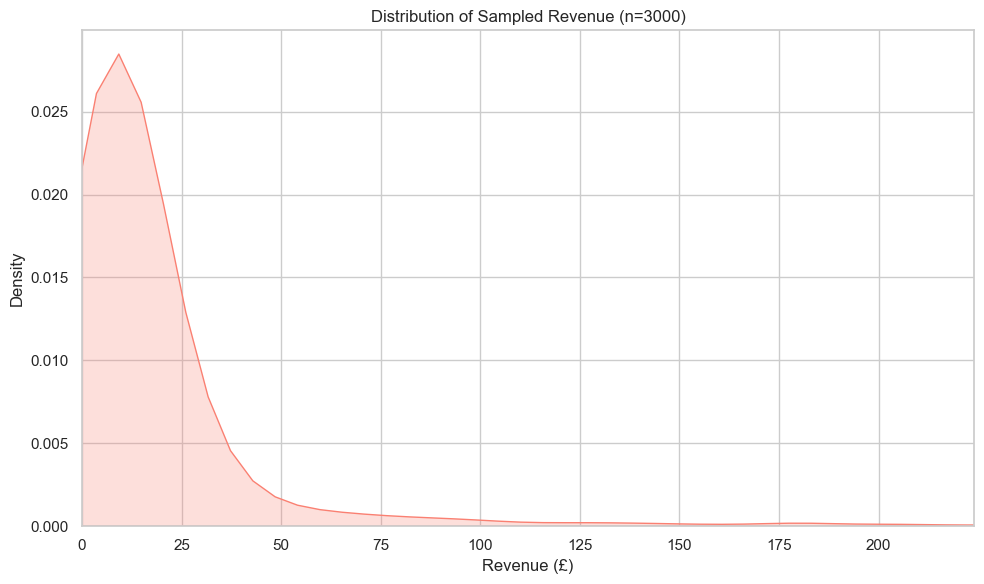

In [89]:
# 3. Draw a histogram and density plot (KDE) to support the conclusion
plt.figure(figsize=(10, 6))
sns.kdeplot(revenue_sample, fill=True, color='salmon')
plt.title('Distribution of Sampled Revenue (n=3000)')
plt.xlabel('Revenue (£)')
plt.ylabel('Density')

# To make the plot readable despite massive outliers, we'll limit the x-axis 
# to the 99th percentile of the sample just for visual clarity
plt.xlim(0, revenue_sample.quantile(0.99)) 

plt.tight_layout()
plt.show()

#### Visual Analysis:
- **Severe Right-Skewness:** The density plot vividly illustrates that the sampled revenue is heavily right-skewed, lacking the symmetrical bell shape of a normal distribution.
- **Low-Value Concentration:** The vast majority of line items are concentrated at the very lower end of the scale, with the density peaking steeply between £0 and £25.
- **The "Long Tail":** The trailing line extending far to the right (past £200) visually confirms the presence of occasional, high-value transactions.
- **Violation of Normality:** This visualization perfectly supports your Shapiro-Wilk test result, providing clear visual evidence that the e-commerce revenue data strictly violates the assumption of normality.

---

### Test 2: Association between quantity and unit price

**Question:** Is there an association between quantity ordered and unit price?

**Hypotheses:**
* **$H_0$:** There is no monotonic association between quantity and unit price.
* **$H_1$:** There is a monotonic association between quantity and unit price.

**Methodology:**
To evaluate this relationship, we will use the `Quantity` and `UnitPrice` columns from our cleaned dataset (which only contains positive values). Because both variables are numeric, highly skewed, and the relationship is likely not strictly linear, we will utilize a Spearman rank correlation (`scipy.stats.spearmanr`) rather than a standard Pearson correlation.

In [90]:
from scipy.stats import spearmanr

In [91]:
# 1. Select the two columns required for the test
# We use df_clean to ensure we only use positive values as instructed earlier
quantity_data = df_clean['Quantity']
price_data = df_clean['UnitPrice']

In [92]:
# 2. Run the Spearman rank correlation test
correlation_coef, p_value = spearmanr(quantity_data, price_data)

In [93]:
# 3. Report test statistic, p-value, and relevant summaries
print("Spearman Rank Correlation Results")
print("---------------------------------")
print(f"Sample Size (n):         {len(df_clean)}")
print(f"Spearman Coefficient:    {correlation_coef:.4f}")
print(f"P-value:                 {p_value:.4e}")

# Basic programmatic interpretation for the notebook output
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (p < 0.05).")
    print("There is a statistically significant monotonic relationship between Quantity and Unit Price.")
else:
    print("\nConclusion: Fail to reject the null hypothesis (p >= 0.05).")
    print("There is no statistically significant monotonic relationship between Quantity and Unit Price.")

Spearman Rank Correlation Results
---------------------------------
Sample Size (n):         530104
Spearman Coefficient:    -0.4032
P-value:                 0.0000e+00

Conclusion: Reject the null hypothesis (p < 0.05).
There is a statistically significant monotonic relationship between Quantity and Unit Price.


---

### Test 3: Difference in revenue between the United Kingdom and other countries

**1. Question:** Do line item revenues differ on average between the United Kingdom and all other countries combined?

**2. Hypotheses:**
* **$H_0$ (Null Hypothesis):** The mean revenue of line items from the United Kingdom is equal to the mean revenue of line items from all other countries ($\mu_{UK} = \mu_{Other}$).
* **$H_1$ (Alternative Hypothesis):** The mean revenue of line items from the United Kingdom is not equal to the mean revenue of line items from all other countries ($\mu_{UK} \neq \mu_{Other}$).

In [94]:
from scipy.stats import ttest_ind

In [95]:
# 1. Split the data into two groups based on the Country column
# Note: Ensure 'Country' matches the exact capitalization in your dataframe
uk_revenue = df_clean[df_clean['Country'] == 'United Kingdom']['Revenue']
other_revenue = df_clean[df_clean['Country'] != 'United Kingdom']['Revenue']

In [96]:
# 2. Calculate group means for reporting
mean_uk = uk_revenue.mean()
mean_other = other_revenue.mean()

In [97]:
# 3. Run the appropriate test in Python (Two-sample t-test)
t_stat, p_value = ttest_ind(uk_revenue, other_revenue, equal_var=False)

In [98]:
# 4. Report test statistic, p-value, and relevant summary statistics
print("Two-Sample T-Test Results")
print("-------------------------")
print(f"Mean Revenue (UK):          £{mean_uk:.2f}")
print(f"Mean Revenue (Other):       £{mean_other:.2f}")
print(f"T-Statistic:                {t_stat:.4f}")
print(f"P-value:                    {p_value:.4e}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (p < 0.05).")
    if mean_uk > mean_other:
        print("The United Kingdom has a significantly higher average revenue.")
    else:
        print("The combined 'Other' countries have a significantly higher average revenue.")
else:
    print("\nConclusion: Fail to reject the null hypothesis (p >= 0.05).")
    print("There is no significant difference in average revenue between the UK and other countries.")

Two-Sample T-Test Results
-------------------------
Mean Revenue (UK):          £18.60
Mean Revenue (Other):       £36.49
T-Statistic:                -30.8258
P-value:                    4.9985e-208

Conclusion: Reject the null hypothesis (p < 0.05).
The combined 'Other' countries have a significantly higher average revenue.


---

### Test 4: Revenue across top countries

**1. Question:** Among the top countries by number of transactions, are the mean revenues the same?

**2. Hypotheses:**
* **$H_0$ (Null Hypothesis):** The mean revenue is equal across the top five countries ($\mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5$).
* **$H_1$ (Alternative Hypothesis):** At least one of the top five countries has a mean revenue that is significantly different from the others.

**Methodology:**
We will identify the five countries with the highest number of transactions (rows) in our dataset. We will then filter the data to include only these countries and apply a One-Way ANOVA (`scipy.stats.f_oneway`) to compare their mean revenues.

In [99]:
from scipy.stats import f_oneway

In [100]:
# 1. Identify the top 5 countries by number of transactions 
top_5_countries = df_clean['Country'].value_counts().head(5).index.tolist()
print(f"Top 5 Countries by transaction volume: {top_5_countries}")

Top 5 Countries by transaction volume: ['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain']


In [101]:
# 2. Filter the data to keep only these 5 countries
df_top5 = df_clean[df_clean['Country'].isin(top_5_countries)]

In [102]:
# 3. Calculate and report the mean revenue for each country
print("Mean Revenue by Country")
print("-----------------------")
means = df_top5.groupby('Country')['Revenue'].mean().sort_values(ascending=False)
for country, mean_val in means.items():
    print(f"{country:<15}: £{mean_val:.2f}")

Mean Revenue by Country
-----------------------
EIRE           : £35.93
Germany        : £25.32
France         : £24.95
Spain          : £24.79
United Kingdom : £18.60


In [103]:
# 4. Extract the revenue values for each country into separate lists/series
# We use a list comprehension to prepare the groups for the ANOVA test
groups = [df_top5[df_top5['Country'] == country]['Revenue'] for country in top_5_countries]

In [104]:
# 5. Run the One-Way ANOVA
# The * operator unpacks the list of series as separate arguments to the function
f_stat, p_value = f_oneway(*groups)

In [105]:
# 6. Report F statistic and p-value
print("One-Way ANOVA Results")
print("-------------------------")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (p < 0.05).")
    print("The mean revenues are NOT the same across the top 5 countries.")
else:
    print("\nConclusion: Fail to reject the null hypothesis (p >= 0.05).")
    print("There is no significant difference in mean revenues across the top 5 countries.")

One-Way ANOVA Results
-------------------------
F-Statistic: 10.2228
P-value:     2.8330e-08

Conclusion: Reject the null hypothesis (p < 0.05).
The mean revenues are NOT the same across the top 5 countries.


---

### Test 5: Association between country and high value purchase

**1. Question:** Is the proportion of high-value purchases the same across the main countries?

**2. Hypotheses:**
* **$H_0$ (Null Hypothesis):** The proportion of high-value purchases is independent of the country (the proportions are equal across the top 5 countries).
* **$H_1$ (Alternative Hypothesis):** The proportion of high-value purchases is dependent on the country (at least one country has a significantly different proportion of high-value purchases).

**Methodology:**
To conduct this test, we must first define a "high-value purchase." We will set this threshold at the 99th percentile of revenue across the entire dataset. We will then filter our data to the top five countries by transaction volume, construct a contingency table of Country vs. High-Value Status, and perform a Chi-Square test of independence (`scipy.stats.chi2_contingency`).

In [106]:
from scipy.stats import chi2_contingency

In [107]:
# 1. Define 'high value' using the 99th percentile of revenue
high_value_threshold = df_clean['Revenue'].quantile(0.99)
print(f"High-Value Threshold (99th Percentile): £{high_value_threshold:.2f}")

High-Value Threshold (99th Percentile): £183.60


In [108]:
# 2. Identify the top 5 countries (if not already done in Test 4)
top_5_countries = df_clean['Country'].value_counts().head(5).index.tolist()

In [109]:
# 3. Filter the dataset to these top 5 countries
df_top5 = df_clean[df_clean['Country'].isin(top_5_countries)].copy()

In [110]:
# 4. Create a binary column for the contingency table
df_top5['is_high_value'] = df_top5['Revenue'] >= high_value_threshold

In [111]:
# 5. Build the Contingency Table
# We use normalize='index' afterwards to see the proportions easily
contingency_table = pd.crosstab(df_top5['Country'], df_top5['is_high_value'])
proportions_table = pd.crosstab(df_top5['Country'], df_top5['is_high_value'], normalize='index') * 100

print("Contingency Table (Counts)")
print("-------------------------------------------")
print(contingency_table)
print("\nPercentage of High-Value Orders by Country")
print("-------------------------------------------")
# Displaying the 'True' column which represents the high-value percentage
print(proportions_table[True].sort_values(ascending=False).map("{:.2f}%".format))

Contingency Table (Counts)
-------------------------------------------
is_high_value    False  True 
Country                      
EIRE              7670    220
France            8352     55
Germany           8969     71
Spain             2449     35
United Kingdom  481063   4060

Percentage of High-Value Orders by Country
-------------------------------------------
Country
EIRE              2.79%
Spain             1.41%
United Kingdom    0.84%
Germany           0.79%
France            0.65%
Name: True, dtype: str


In [112]:
# 6. Run the Chi-Square Test
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

# Report the exact statistics requested
print("Chi-Square Test Results")
print("-------------------------")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom:   {dof}")
print(f"P-value:              {p_value:.4e}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (p < 0.05).")
    print("The proportion of high-value purchases is NOT the same across the main countries.")
else:
    print("\nConclusion: Fail to reject the null hypothesis (p >= 0.05).")
    print("There is no significant difference in the proportion of high-value purchases across these countries.")#

Chi-Square Test Results
-------------------------
Chi-Square Statistic: 358.1028
Degrees of Freedom:   4
P-value:              3.1214e-76

Conclusion: Reject the null hypothesis (p < 0.05).
The proportion of high-value purchases is NOT the same across the main countries.


---

### Conclusions
* **Test 1 (Normality):** The revenue data significantly violates the normality assumption, displaying the extreme right-skewness typical of e-commerce transactions.
* **Test 2 (Correlation):** There is a statistically significant inverse relationship between quantity and unit price, indicating that more expensive items are typically bought in smaller quantities.
* **Test 3 (Mean Comparison):** Average line-item revenues differ significantly between the domestic United Kingdom market and international orders.
* **Test 4 (Group Variance):** Mean transaction revenues vary significantly across the top five highest-volume countries, highlighting distinct regional purchasing behaviors.
* **Test 5 (Independence):** The proportion of high-value, top-percentile purchases is not uniform and is significantly dependent on the customer's country.